# 🌞 Solar Nowcast Validator
This notebook shows you how to use the validator:
1. **Validate** the nowcasts with run_validation.py
3. **Plot** the nowcasts against observations
4.  **Plot** the scores calculated by run_validation.py

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Step 1: Computing scores with `run_validation.py`

Before plotting the scores below, you need to run the validation script from a terminal.
It loads all nowcasts and observations for a date range, aligns them, and saves
MAE and RMSE as NetCDF files in the `results/` folder.

**From the project root directory:**
```bash
uv run python run_validation.py --start 2026-02-26 --end 2026-02-27
```

**Optional arguments:**
| Argument | Default | Description |
|---|---|---|
| `--start` | *(required)* | First nowcast initialization date, e.g. `2026-02-26` |
| `--end` | *(required)* | Last nowcast initialization date, e.g. `2026-02-27` |
| `--nwc-dir` | `/dmidata/projects/energivejr/nowcasts` | Path to nowcast files |
| `--obs-dir` | `/dmidata/projects/energivejr/satellite_data` | Path to observation files |
| `--output-dir` | `results/` | Where to write the output `.nc` files |

**Output files written to `results/`:**
- `mae_<start>_<end>.nc` — Mean Absolute Error per `(lead_time, lat, lon)`
- `rmse_<start>_<end>.nc` — Root Mean Squared Error per `(lead_time, lat, lon)`

Once the script finishes, run the cell below to load and plot the scores.

---




Loading nowcast for 2026-02-26 11:00:00 ...
  Found 1 nowcast files.
Loading observations up to 2026-02-26 17:00:00 ...


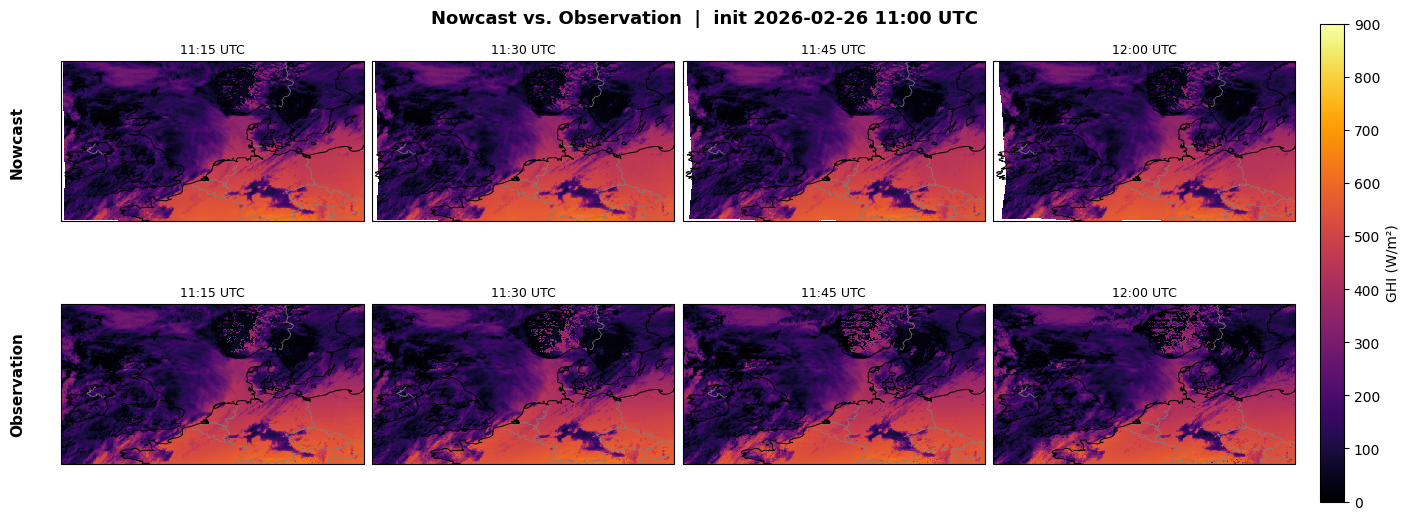

In [ ]:
# --- Step 2: Nowcast vs. observation sequence ---
import argparse
from plot_results import plot_sequence

NWC_DIR = Path("/dmidata/projects/energivejr/nowcasts")
OBS_DIR = Path("/dmidata/projects/energivejr/satellite_data")

args = argparse.Namespace(
    init       = "2026-02-26 11:00",  # initialization time to plot
    n_steps    = 4,                    # number of lead steps to show
    step_every = 1,                    # stride (1 = every 15 min)
    vmin       = 0,
    vmax       = 900,
    nwc_dir    = str(NWC_DIR),
    obs_dir    = str(OBS_DIR),
    save_dir   = None,
)

plot_sequence(args)


Loading scores from mae_20260226_20260227.nc / rmse_20260226_20260227.nc ...


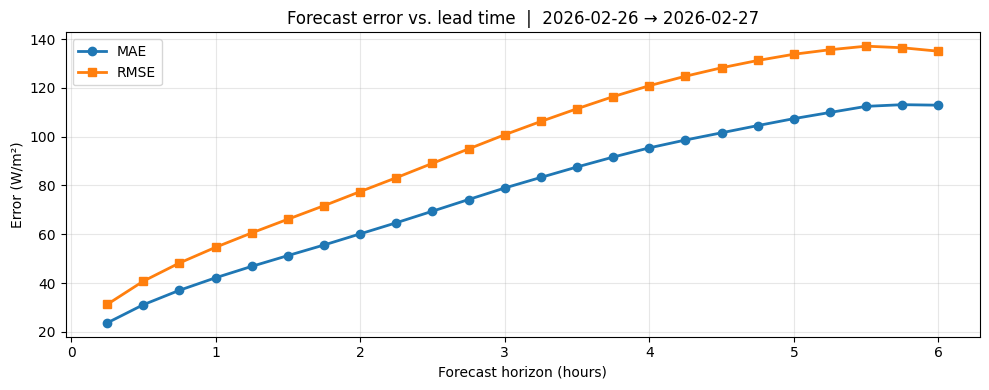

In [4]:
# --- Step 3: Plot scores from run_validation.py ---
import argparse
from plot_results import plot_scores

args = argparse.Namespace(
    scores_start = "2026-02-26",
    scores_end   = "2026-02-27",
    results_dir  = str(Path("..") / "results"),
    save_dir     = None,
)

plot_scores(args)

> **Tip:** Both plots in this notebook are also available as a standalone script — `plot_results.py` — which you can run from the terminal without opening the notebook after running the `run_validation.py`:
> ```bash
> # Both plots at once:
> uv run python plot_results.py --init "2026-02-26 11:00" --scores-start 2026-02-26 --scores-end 2026-02-27
> 
> # Sequence plot only:
> uv run python plot_results.py --init "2026-02-26 11:00" --no-scores
> 
> # Scores plot only:
> uv run python plot_results.py --scores-only --scores-start 2026-02-26 --scores-end 2026-02-27
> 
> # Save figures to disk instead of showing them:
> uv run python plot_results.py --init "2026-02-26 11:00" --scores-start 2026-02-26 --scores-end 2026-02-27 --save-dir figures/
> ```